# Danish Psychiatric Drug Consumption — Population-Level Analysis
### Source: medstat.dk (Danish Medicines Agency)

Downloads, processes and visualises population-level psychiatric
prescription statistics from the Danish public medicines statistics portal.

**What medstat.dk** covers all dispensed prescriptions in Denmark
since 1996, broken down by ATC code, year, sex, and age group. it is not individual patient data. You cannot build trajectories from it.
It provides the macro/population context that motivates the patient-level pipeline.

**Psychiatric ATC groups covered:**
| ATC | Name |
|-----|------|
| N05A | Antipsychotics |
| N05B | Anxiolytics |
| N05C | Hypnotics and sedatives |
| N06A | Antidepressants |
| N06D | Anti-dementia drugs |

## Step 1 — Download data from medstat.dk

1. Go to **https://medstat.dk/en**
2. Click **"Statistics"** in the top menu
3. Select **"Drug consumption"**
4. Under **ATC group**, type `N05A` → select it → click **"Add"**
5. Repeat for `N05B`, `N05C`, `N06A`, `N06D`
6. Set **Period**: 2000–2023 (or maximum available) (but i did from 1996)
7. Set **Presentation**: *Per 1000 inhabitants per day* (this is DDDs/1000/day — the standard unit)
8. Click **"Show statistics"**
9. Click **"Download"** → choose **Excel (.xlsx)**
10. Save file as `data/medstat_???.xlsx` in this project folder

## Step 2 — Load and inspect the data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Style 
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'figure.dpi':       150,
})

PALETTE = {
    'N05A': '#E63946',   # antipsychotics   — red
    'N05B': '#457B9D',   # anxiolytics      — steel blue
    'N05C': '#2A9D8F',   # hypnotics        — teal
    'N06A': '#264653',   # antidepressants  — dark slate
    'N06D': '#F4A261',   # anti-dementia    — amber
}

LABELS = {
    'N05A': 'Antipsychotics (N05A)',
    'N05B': 'Anxiolytics (N05B)',
    'N05C': 'Hypnotics & Sedatives (N05C)',
     # NOTE: DDD values use national assignments for some drugs (medstat footnotes 1,3). Not directly comparable to international DDD databases.
    'N06A': 'Antidepressants (N06A)',
    'N06D': 'Anti-dementia (N06D)',
}

# ── Load 
xl_path = Path('data/medstat_volume_primary_sex.xlsx')
assert xl_path.exists(), (
    'File not found. Complete Step 1 first (manual or programmatic download).'
)

# medstat.dk exports typically have a header block before the data table.
# We read with header=None first to find where the actual data starts.
raw = pd.read_excel(xl_path, header=None)
print('Raw shape:', raw.shape)
print(raw.head(10).to_string())

Raw shape: (71, 27)
                                                           0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23   24   25   26
0                                                  MEDSTAT.DK  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
1                      ATC code: N05A, N05B, N05C, N06A, N06D  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2  Search variable: Volume sold per 1,000 inhabitants per day  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
3                                             Age groups: All  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
4                   

In [14]:
import pandas as pd
from pathlib import Path

def parse_medstat_chunked(filepath, value_name):
    """Parses Medstat files that are grouped into chunks by ATC code."""
    # Read the file blindly without headers
    if str(filepath).endswith('.csv'):
        df_raw = pd.read_csv(filepath, header=None)
    else:
        df_raw = pd.read_excel(filepath, header=None)
        
    records = []
    
    # Iterate through all rows looking for the ATC "chunk" headers
    for i in range(len(df_raw)):
        cell_0 = str(df_raw.iloc[i, 0])
        
        # When we find a row starting with "ATC code: N..."
        #if 'ATC code:' in cell_0 and 'Search variable' not in cell_0:
        # When we find a row starting with "ATC code: N..." AND it has parentheses
        if str(cell_0).startswith('ATC code:') and '(' in str(cell_0):
            
            # Extract the 4-letter ATC code (e.g., 'ATC code: N05A' -> 'N05A')
            atc_group = cell_0.split(':')[1].strip().split(' ')[0]
            
            # The years are always 2 rows below the ATC header
            years = df_raw.iloc[i+2, 1:].values
            
            # Male data is always 6 rows below
            male_row = df_raw.iloc[i+6]
            male_sex = male_row[0]
            male_vals = male_row[1:].values
            
            # Female data is always 7 rows below
            female_row = df_raw.iloc[i+7]
            female_sex = female_row[0]
            female_vals = female_row[1:].values

            assert str(male_sex).strip().lower() in ('male', 'men', 'mænd'), \
                f"Format error! Expected Male label at row {i+6}, got: '{male_sex}'"
            assert str(female_sex).strip().lower() in ('female', 'women', 'kvinder'), \
                f"Format error! Expected Female label at row {i+7}, got: '{female_sex}'"

            # Match each year with its value
            for y, m_val, f_val in zip(years, male_vals, female_vals):
                if pd.notna(y): 
                    records.append({'atc_group': atc_group, 'year': int(y), 'sex': male_sex, value_name: m_val})
                    records.append({'atc_group': atc_group, 'year': int(y), 'sex': female_sex, value_name: f_val})
                    
    df_clean = pd.DataFrame(records)
    
    # Clean numeric values (replace '-' or '>99%' with NaNs)
    df_clean[value_name] = pd.to_numeric(df_clean[value_name].astype(str).replace(['-', '>99%', 'NaN'], 'nan'), errors='coerce')
    
    return df_clean

# Update these filenames to exactly match what is in your data folder
vol_path = Path('data/medstat_volume_primary_sex.xlsx')
pat_path = Path('data/medstat_patients_primary_sex.xlsx')

# 1. Parse both files using our new custom function
print("Loading Volume file...")
df_vol = parse_medstat_chunked(vol_path, 'ddd_per_1000')

print("Loading Patient file...")
df_pat = parse_medstat_chunked(pat_path, 'n_patients')

# 2. Merge them together on Year, ATC Group, and sex
combined_df = pd.merge(df_vol, df_pat, on=['year', 'atc_group', 'sex'], how='inner')

# 3. Calculate ecological treatment intensity proxy
# Formula: (DDD/1000_sex/day × 365) / (users/1000_sex) → DDD per prevalent user per year.
# Both numerator and denominator share the same sex-specific per-1000 denominator,
# which cancels algebraically. The result is a POPULATION-LEVEL ecological ratio:
# it cannot distinguish higher daily dose from longer treatment duration, and
# should not be interpreted as an individual-level adherence or intensity measure.
combined_df['ddd_per_patient_year'] = (combined_df['ddd_per_1000'] * 365) / combined_df['n_patients']

print(f"Data successfully loaded and merged! Total rows: {len(combined_df)}")
print(combined_df.head())

Loading Volume file...
Loading Patient file...
Data successfully loaded and merged! Total rows: 260
  atc_group  year     sex  ddd_per_1000  n_patients  ddd_per_patient_year
0      N05A  2000    Male           8.3       16.18            187.237330
1      N05A  2000  Female           8.0       24.32            120.065789
2      N05A  2001    Male           8.9       16.29            199.416820
3      N05A  2001  Female           8.4       23.99            127.803251
4      N05A  2002    Male           9.7       16.63            212.898376


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── Style & Colors ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'figure.dpi':       150,
})

PALETTE = {'N05A': '#E63946', 'N05B': '#457B9D', 'N05C': '#2A9D8F', 'N06A': '#264653', 'N06D': '#F4A261'}
LABELS = {'N05A': 'Antipsychotics (N05A)', 'N05B': 'Anxiolytics (N05B)', 'N05C': 'Hypnotics & Sedatives (N05C)', 'N06A': 'Antidepressants (N06A)', 'N06D': 'Anti-dementia (N06D)'}
PSYCH_GROUPS = ['N05A', 'N05B', 'N05C', 'N06A', 'N06D']
# N06D (anti-dementia: donepezil, memantine, galantamine) is included because:
#1. It shares the N06 psychoanaleptics branch with antidepressants.
#2. Cognitive pharmacotherapy is increasingly relevant to late-life psychiatric comorbidity (depression in dementia, psychosis in dementia).
#3. Its >1000% growth since 2000 illustrates a qualitatively different trend from the psychiatric stabilisation/decline seen in N05 groups.
#Exclude it from any comparative dose analysis given N05C-style DDD caveats.

# ── Recreate the overall group_year dataframe for standard plots ──────────
# Assuming roughly 50/50 population split, the mean of Male/Female rates 
# gives us a highly accurate estimate of the overall population rate.
group_year = combined_df.groupby(['year', 'atc_group'], as_index=False).agg({
    'ddd_per_1000': 'mean',
    'n_patients': 'mean'
})
print("Overall 'group_year' created successfully!")

Overall 'group_year' created successfully!


## 3. Plot 

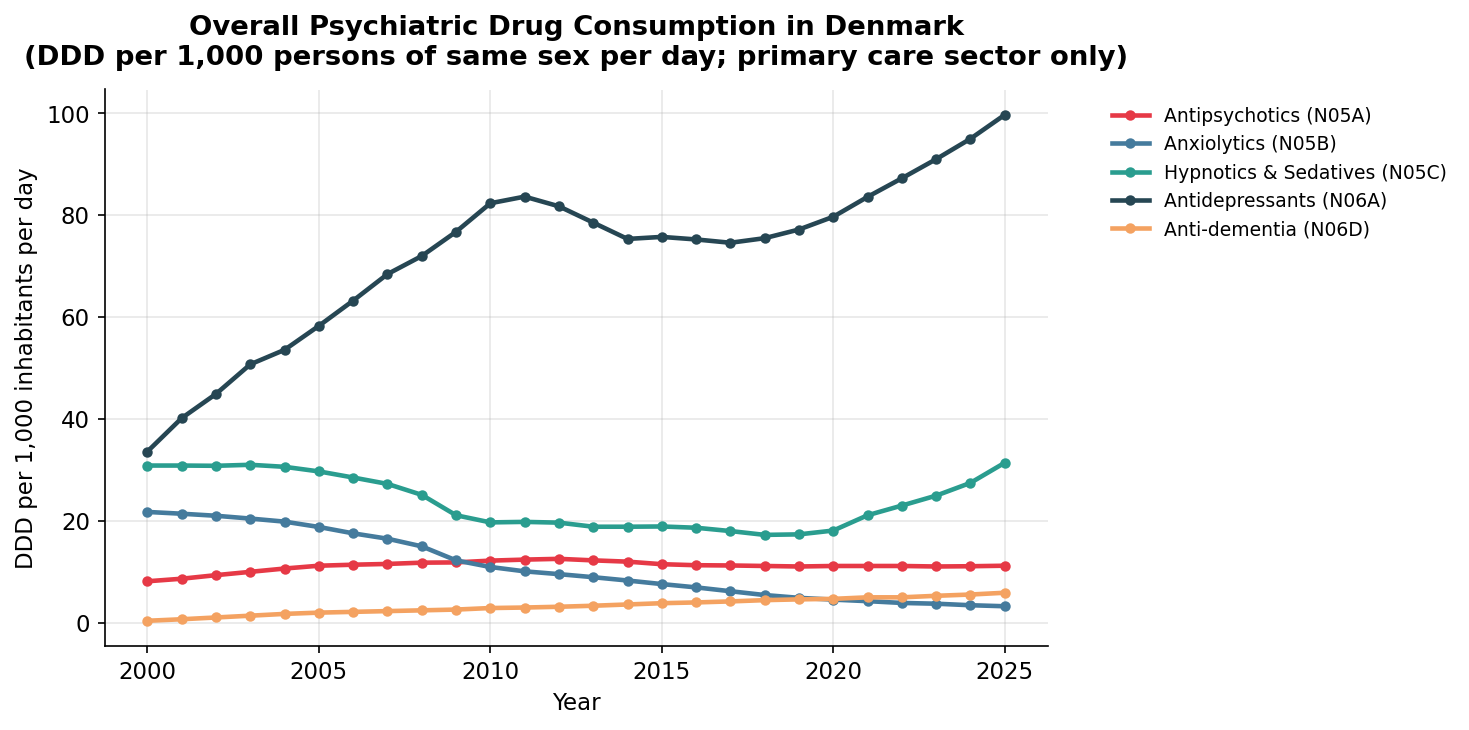

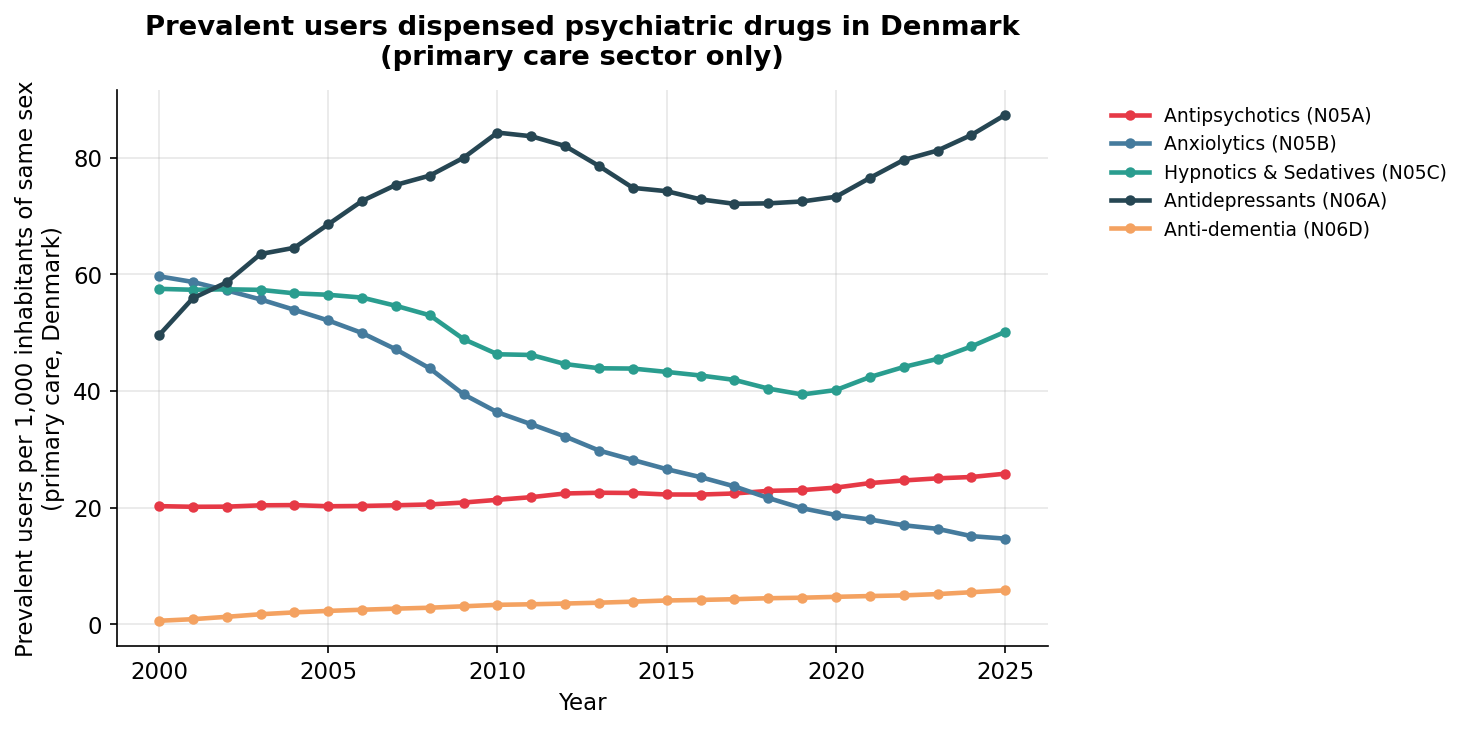

In [16]:
# ── Figure 1: DDD consumption trends over time
fig, ax = plt.subplots(figsize=(10, 5))
for grp in PSYCH_GROUPS:
    sub = group_year[group_year['atc_group'] == grp].sort_values('year')
    ax.plot(sub['year'], sub['ddd_per_1000'], color=PALETTE[grp], linewidth=2.2, marker='o', markersize=4, label=LABELS[grp])

ax.set_xlabel('Year')
ax.set_ylabel('DDD per 1,000 inhabitants per day')
ax.set_title('Overall Psychiatric Drug Consumption in Denmark\n(DDD per 1,000 persons of same sex per day; primary care sector only)', fontweight='bold', pad=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig1_ddd_trends.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Figure 2: Number of patients 
fig, ax = plt.subplots(figsize=(10, 5))
for grp in PSYCH_GROUPS:
    sub = group_year[group_year['atc_group'] == grp].sort_values('year')
    ax.plot(sub['year'], sub['n_patients'], color=PALETTE[grp], linewidth=2.2, marker='o', markersize=4, label=LABELS[grp])

ax.set_xlabel('Year')
ax.set_ylabel('Prevalent users per 1,000 inhabitants of same sex\n(primary care, Denmark)')
ax.set_title('Prevalent users dispensed psychiatric drugs in Denmark\n(primary care sector only)', fontweight='bold', pad=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig2_patient_counts.png', dpi=200, bbox_inches='tight')
plt.show()

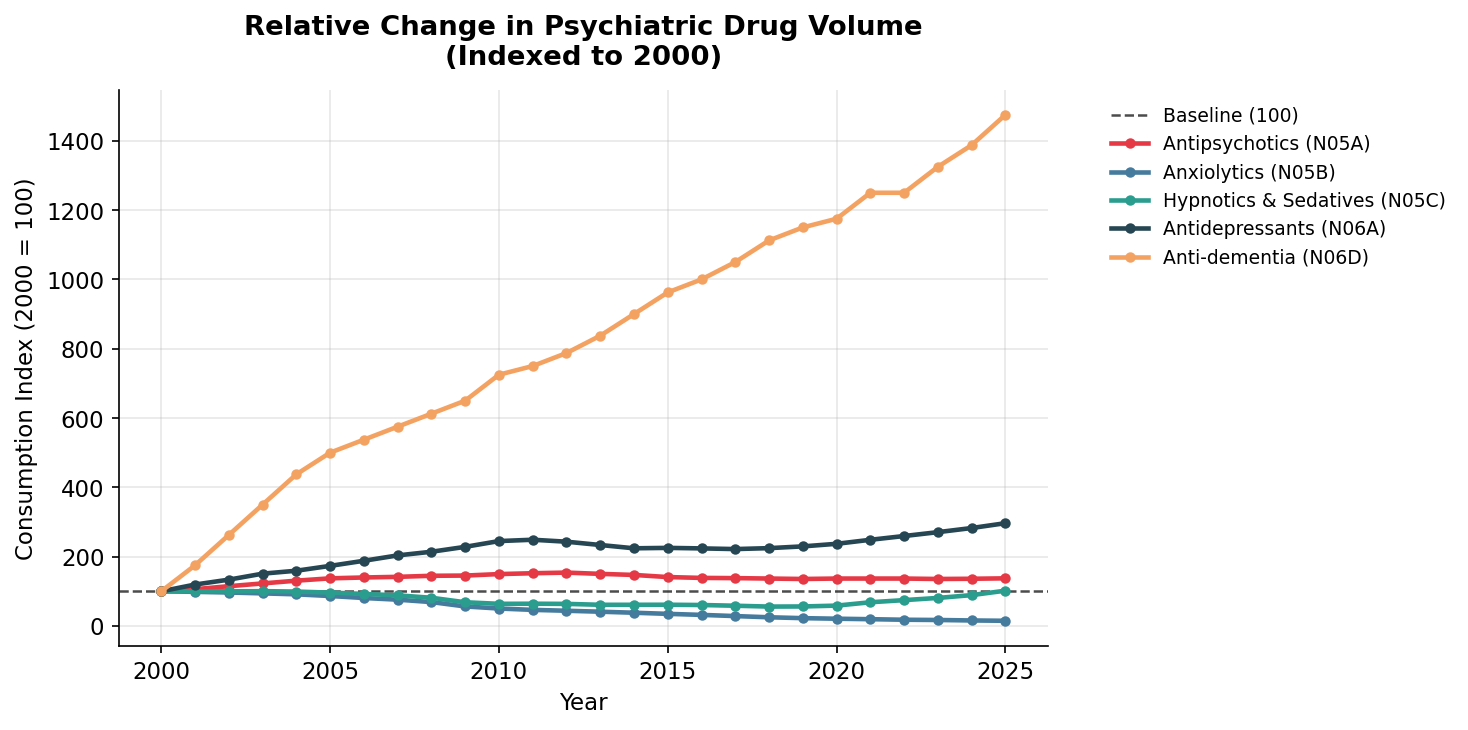

Saved → figures/fig3_indexed_trends.png


In [17]:
# ── Figure 3: Relative change since baseline (index = 100) 
BASE_YEAR = group_year['year'].min()

fig, ax = plt.subplots(figsize=(10, 5))
# Add a bold reference line at 100 (Baseline)
ax.axhline(100, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='Baseline (100)')

for grp in PSYCH_GROUPS:
    sub = group_year[group_year['atc_group'] == grp].sort_values('year').copy()
    if sub.empty:
        continue
        
    base_val = sub.loc[sub['year'] == BASE_YEAR, 'ddd_per_1000'].values
    if len(base_val) == 0 or base_val[0] == 0:
        continue
        
    # Calculate index: (Current Year / Base Year) * 100
    sub['indexed'] = (sub['ddd_per_1000'] / base_val[0]) * 100
    
    ax.plot(
        sub['year'], sub['indexed'],
        color=PALETTE[grp], linewidth=2.2, marker='o', markersize=4,
        label=LABELS[grp]
    )

ax.set_xlabel('Year')
ax.set_ylabel(f'Consumption Index ({BASE_YEAR} = 100)')
ax.set_title(
    f'Relative Change in Psychiatric Drug Volume\n(Indexed to {BASE_YEAR})',
    fontweight='bold', pad=12
)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig3_indexed_trends.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figures/fig3_indexed_trends.png')

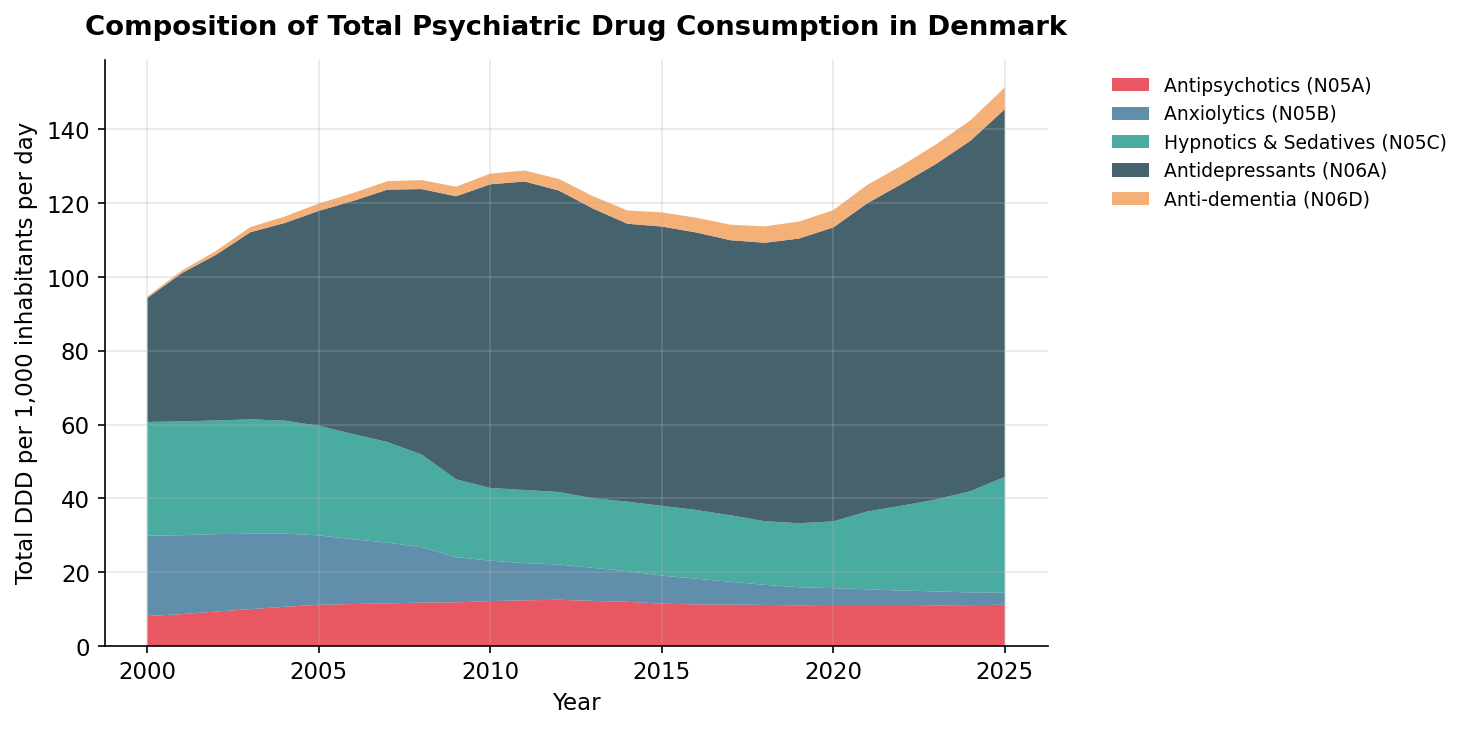

Saved → figures/fig4_stacked_area.png


In [18]:
# ── Figure 4: Stacked area — share of total psychiatric consumption 
pivot = (
    group_year[group_year['atc_group'].isin(PSYCH_GROUPS)]
    .pivot_table(index='year', columns='atc_group', values='ddd_per_1000', aggfunc='sum')
    .fillna(0)
)
# Ensure columns match the specific order of PSYCH_GROUPS
pivot = pivot[[g for g in PSYCH_GROUPS if g in pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(
    pivot.index,
    [pivot[g] for g in pivot.columns],
    labels=[LABELS[g] for g in pivot.columns],
    colors=[PALETTE[g] for g in pivot.columns],
    alpha=0.85
)
ax.set_xlabel('Year')
ax.set_ylabel('Total DDD per 1,000 inhabitants per day')
ax.set_title(
    'Composition of Total Psychiatric Drug Consumption in Denmark',
    fontweight='bold', pad=12
)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig4_stacked_area.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figures/fig4_stacked_area.png')

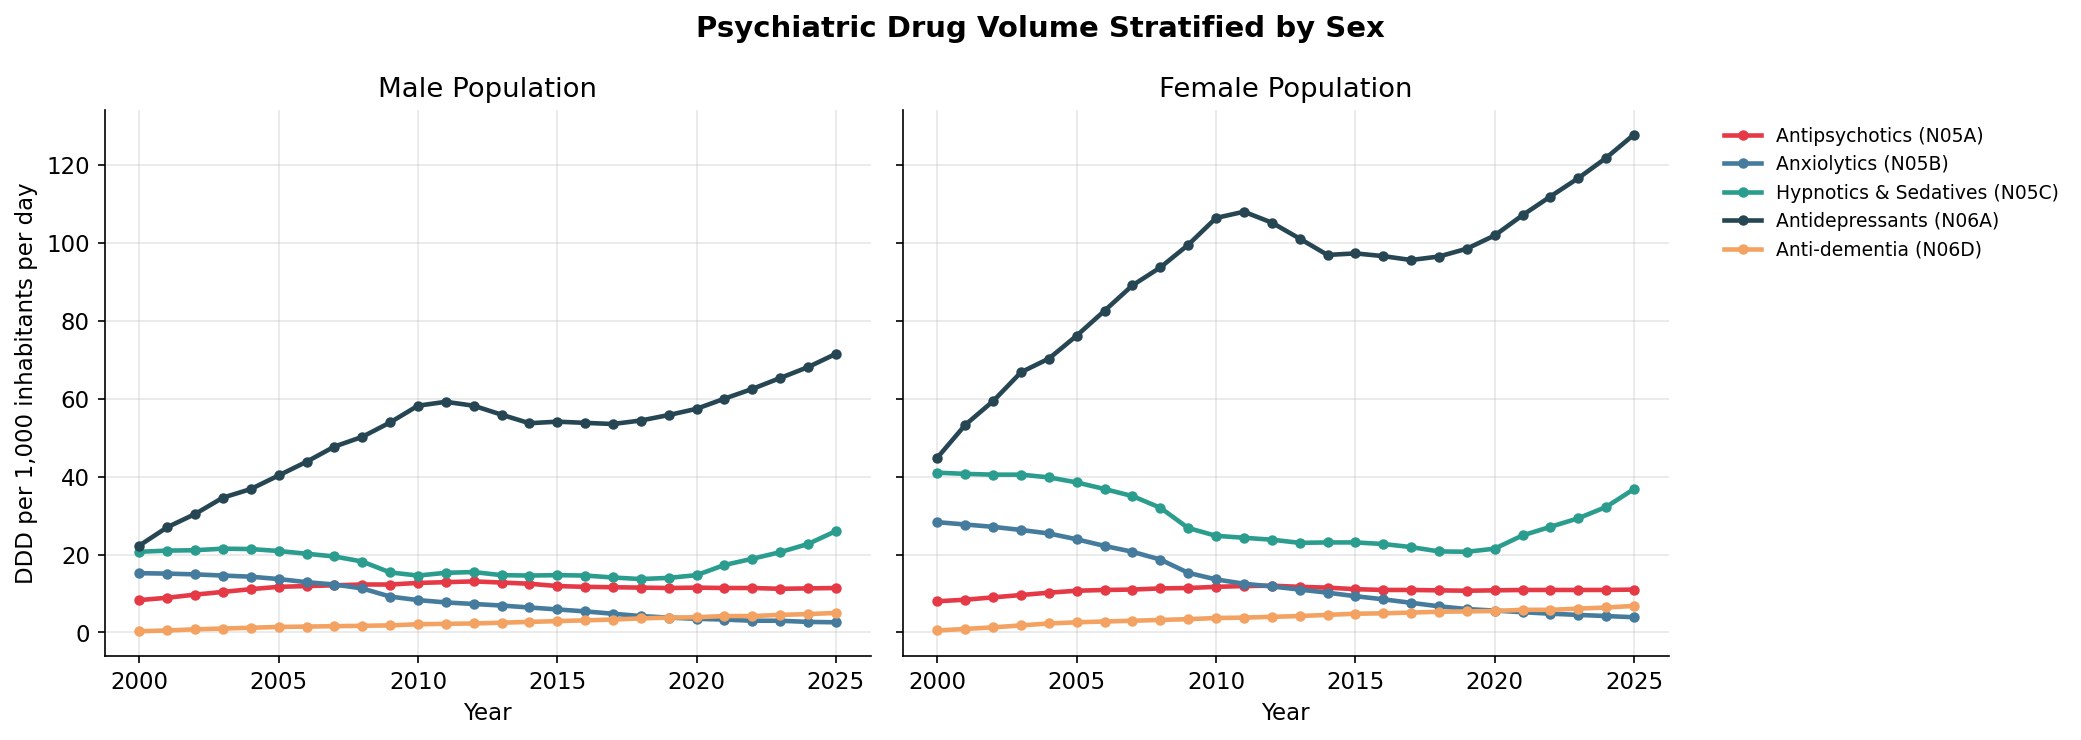

Saved → figures/fig5_sex_breakdown.png


In [19]:
# ── Figure 5: Sex Breakdown (Volume of Consumption) 
# Create two side-by-side plots with a shared Y-axis for honest comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Psychiatric Drug Volume Stratified by Sex', fontweight='bold', fontsize=14)

for ax, sex_target in zip(axes, ['Male', 'Female']):
    for grp in PSYCH_GROUPS:
        # EXACT match to prevent "Female" from triggering a match for "M"
        sub = combined_df[
            (combined_df['atc_group'] == grp) & 
            (combined_df['sex'] == sex_target)
        ].sort_values('year')
        
        if sub.empty:
            continue
            
        ax.plot(
            sub['year'], sub['ddd_per_1000'],
            color=PALETTE[grp], linewidth=2.2, marker='o', markersize=4,
            label=LABELS[grp]
        )
        
    ax.set_title(f'{sex_target} Population')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('DDD per 1,000 inhabitants per day')
# Only put the legend on the right plot to save space
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig5_sex_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figures/fig5_sex_breakdown.png')

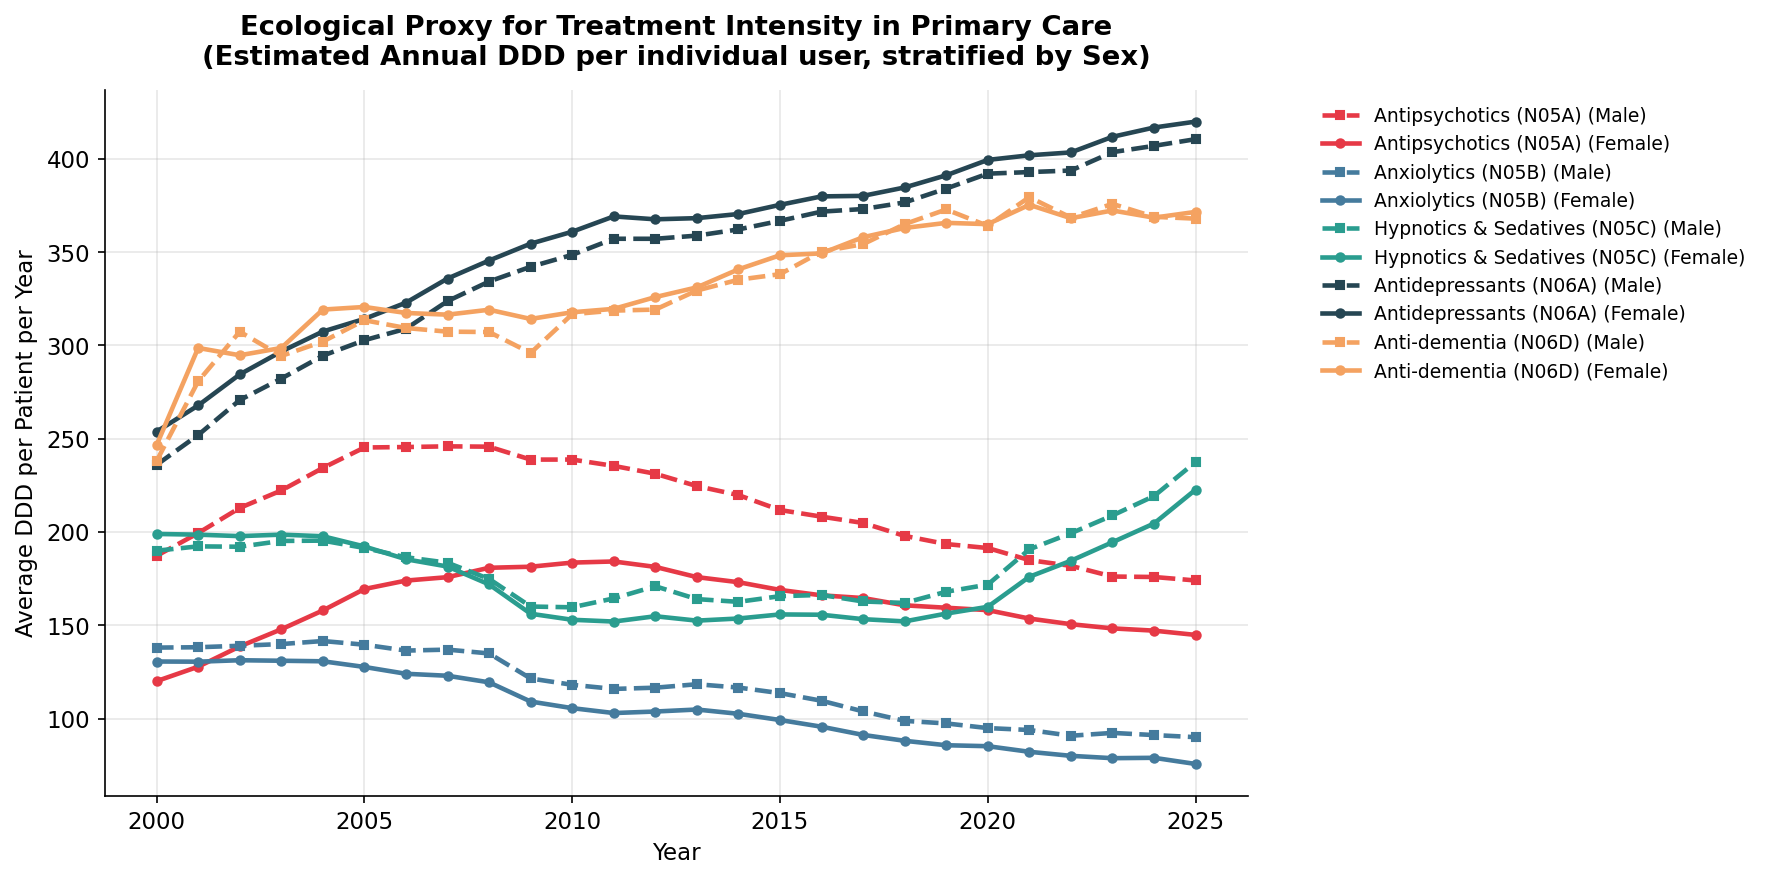

Saved → figures/fig6_intensity_by_sex.png


In [20]:
# ── Figure 6: Average Treatment Intensity by Sex
fig, ax = plt.subplots(figsize=(12, 6))

for grp in PSYCH_GROUPS:
    for sex in combined_df['sex'].unique():
        sub = combined_df[(combined_df['atc_group'] == grp) & (combined_df['sex'] == sex)].sort_values('year')
        if sub.empty:
            continue
            
        # Solid lines for Female, Dashed lines for Male
        line_style = '--' if 'Male' in str(sex) else '-' 
        
        ax.plot(
            sub['year'], sub['ddd_per_patient_year'],
            color=PALETTE[grp], 
            linewidth=2.2, 
            linestyle=line_style,
            marker='o' if line_style == '-' else 's', 
            markersize=4,
            label=f"{LABELS[grp]} ({sex})"
        )

ax.set_xlabel('Year')
ax.set_ylabel('Average DDD per Patient per Year')
ax.set_title(
    'Ecological Proxy for Treatment Intensity in Primary Care\n'
    '(Estimated Annual DDD per individual user, stratified by Sex)',
    fontweight='bold', pad=12
)

# Put legend outside the plot so it doesn't cover the data
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig6_intensity_by_sex.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figures/fig6_intensity_by_sex.png')

Figure 6: Ecological treatment intensity proxy. Note that this measure reflects population-level interactions of dose and duration; it is not a direct individual-level measurement of adherence or prescribed daily dosing. To resolve this ecological limitation, patient-level trajectory modeling was utilized...

In [21]:
# ── Summary statistics table for thesis
BASE_YEAR = combined_df['year'].min()
RECENT_YEAR = combined_df['year'].max()

# Helper to calculate relative percentage change
def calc_pct(b, r):
    if len(b) > 0 and len(r) > 0 and b[0] > 0:
        return f"{((r[0] - b[0]) / b[0] * 100):+.1f}%"
    return "N/A"

summary_rows = []
for grp in PSYCH_GROUPS:
    # 1. Overall data
    sub_overall = group_year[group_year['atc_group'] == grp]
    base_all = sub_overall.loc[sub_overall['year'] == BASE_YEAR, 'ddd_per_1000'].values
    rec_all = sub_overall.loc[sub_overall['year'] == RECENT_YEAR, 'ddd_per_1000'].values
    
    # 2. Male data
    sub_m = combined_df[(combined_df['atc_group'] == grp) & (combined_df['sex'].str.lower().str.startswith('m'))]
    base_m = sub_m.loc[sub_m['year'] == BASE_YEAR, 'ddd_per_1000'].values
    rec_m = sub_m.loc[sub_m['year'] == RECENT_YEAR, 'ddd_per_1000'].values
    
    # 3. Female data (handles 'Female' or Danish 'Kvinder')
    sub_f = combined_df[(combined_df['atc_group'] == grp) & (combined_df['sex'].str.lower().str.match('f|k'))]
    base_f = sub_f.loc[sub_f['year'] == BASE_YEAR, 'ddd_per_1000'].values
    rec_f = sub_f.loc[sub_f['year'] == RECENT_YEAR, 'ddd_per_1000'].values

    summary_rows.append({
        'ATC Group': grp,
        'Description': LABELS[grp],
        f'Vol ({BASE_YEAR})': round(base_all[0], 2) if len(base_all) else None,
        f'Vol ({RECENT_YEAR})': round(rec_all[0], 2) if len(rec_all) else None,
        'Total Δ (%)': calc_pct(base_all, rec_all),
        'Male Δ (%)': calc_pct(base_m, rec_m),
        'Female Δ (%)': calc_pct(base_f, rec_f)
    })

summary_df = pd.DataFrame(summary_rows)

# Print nice table to console
print(f"--- Changes in Volume (DDD per 1000/day) from {BASE_YEAR} to {RECENT_YEAR} ---")
print(summary_df.to_string(index=False))

# Save for thesis
summary_df.to_csv('data/medstat_summary_table.csv', index=False)
print('\nSaved → data/medstat_summary_table.csv')

--- Changes in Volume (DDD per 1000/day) from 2000 to 2025 ---
ATC Group                  Description  Vol (2000)  Vol (2025) Total Δ (%) Male Δ (%) Female Δ (%)
     N05A        Antipsychotics (N05A)        8.15       11.20      +37.4%     +37.3%       +37.5%
     N05B           Anxiolytics (N05B)       21.75        3.25      -85.1%     -82.9%       -86.2%
     N05C Hypnotics & Sedatives (N05C)       30.85       31.40       +1.8%     +25.6%       -10.2%
     N06A       Antidepressants (N06A)       33.60       99.65     +196.6%    +220.6%      +184.6%
     N06D         Anti-dementia (N06D)        0.40        5.90    +1375.0%   +1566.7%     +1260.0%

Saved → data/medstat_summary_table.csv
